# Association Rule Mining C1 — Streaming Series

## Role 1: Setup, EDA and Transaction Building

This section prepares the streaming series dataset for Association Rule Mining. 
It covers initial exploratory data analysis, construction of viewing-session 
transactions, basket-size analysis, and creation of a separate show lookup table.

In [116]:
import pandas as pd
import numpy as np


pd.set_option("display.max_columns", None)

In [117]:
df = pd.read_csv("../data/streaming_series_watched.csv")

df.head()

,ls dataviewing_session_id,transaction_date,show_id,item_name,category,avg_episode_minutes
0,1,2025-05-07,S05,Office Antics,Sitcom,22
1,1,2025-05-07,S02,The Detective,Crime Drama,50
2,1,2025-05-07,S08,Time Anomaly,Sci-Fi,48
3,2,2025-06-11,S04,Laugh Track,Sitcom,25
4,2,2025-06-11,S05,Office Antics,Sitcom,22


## 1. Exploratory Data Analysis (EDA)

The first step is to inspect the structure, dimensions, data types, missing values, and basic characteristics of the streaming-series dataset.

In [118]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset Information:")
df.info()

Number of rows: 8035
Number of columns: 6

Columns:
['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ls dataviewing_session_id  8035 non-null   int64
 1   transaction_date           8035 non-null   str  
 2   show_id                    8035 non-null   str  
 3   item_name                  8035 non-null   str  
 4   category                   8035 non-null   str  
 5   avg_episode_minutes        8035 non-null   int64
dtypes: int64(2), str(4)
memory usage: 376.8 KB


In [119]:
# Missing values
print("Missing values per column:")
display(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:


ls dataviewing_session_id    0
transaction_date             0
show_id                      0
item_name                    0
category                     0
avg_episode_minutes          0
dtype: int64


Number of duplicate rows: 0


In [120]:
print(df.columns.tolist())

['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [121]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [122]:
df = df.rename(columns={
    "ls dataviewing_session_id": "viewing_session_id"
})

print(df.columns.tolist())

['viewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [123]:
df.head()

,viewing_session_id,transaction_date,show_id,item_name,category,avg_episode_minutes
0,1,2025-05-07,S05,Office Antics,Sitcom,22
1,1,2025-05-07,S02,The Detective,Crime Drama,50
2,1,2025-05-07,S08,Time Anomaly,Sci-Fi,48
3,2,2025-06-11,S04,Laugh Track,Sitcom,25
4,2,2025-06-11,S05,Office Antics,Sitcom,22


In [124]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Total records:", len(df))
print("Unique viewing sessions:", df["viewing_session_id"].nunique())
print("Unique shows:", df["show_id"].nunique())
print("Unique item names:", df["item_name"].nunique())
print("Unique transaction dates:", df["transaction_date"].nunique())

print("\nEarliest transaction date:", df["transaction_date"].min())
print("Latest transaction date:", df["transaction_date"].max())

Total records:

 8035
Unique viewing sessions: 3500
Unique shows: 15
Unique item names: 15
Unique transaction dates: 181

Earliest transaction date: 2025-01-01 00:00:00
Latest transaction date: 2025-06-30 00:00:00


In [125]:
basket_sizes = df.groupby("viewing_session_id")["show_id"].nunique()

basket_sizes.describe()

count    3500.000000
mean        2.295714
std         0.847459
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: show_id, dtype: float64

### Basket Size Distribution

A basket represents the unique shows watched during one viewing session. 
The basket-size distribution shows how many sessions contain one, two, three, or more unique shows.

In [126]:
basket_size_distribution = (
    basket_sizes
    .value_counts()
    .sort_index()
    .rename_axis("basket_size")
    .reset_index(name="number_of_sessions")
)

basket_size_distribution

,basket_size,number_of_sessions
0,1,513
1,2,1818
2,3,790
3,4,379


In [ ]:
%pip install --upgrade --force-reinstall matplotlib
import matplotlib.pyplot as plt

basket_size_distribution.plot(
    x="basket_size",
    y="number_of_sessions",
    kind="bar",
    legend=False
)

plt.title("Basket Size Distribution")
plt.xlabel("Number of Unique Shows per Session")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()

## 2. Show Lookup Table

A separate lookup table is created to retain descriptive information about each show. 
This allows the transaction baskets to contain only show identifiers while show names, 
categories, and average episode runtimes remain available for interpretation.

In [ ]:
show_lookup = (
    df[
        ["show_id", "item_name", "category", "avg_episode_minutes"]
    ]
    .drop_duplicates()
    .sort_values("show_id")
    .reset_index(drop=True)
)

show_lookup

,show_id,item_name,category,avg_episode_minutes
0,S01,Crime City,Crime Drama,45
1,S02,The Detective,Crime Drama,50
2,S03,Silent Witness Redux,Crime Drama,42
3,S04,Laugh Track,Sitcom,25
4,S05,Office Antics,Sitcom,22
5,S06,Space Frontier,Sci-Fi,55
6,S07,Galactic Wars,Sci-Fi,60
7,S08,Time Anomaly,Sci-Fi,48
8,S09,Toon Town,Kids,20
9,S10,Little Explorers,Kids,18


In [ ]:
print("Number of unique shows:", df["show_id"].nunique())
print("Rows in lookup table:", len(show_lookup))
print("Duplicate show IDs:", show_lookup["show_id"].duplicated().sum())

Number of unique shows: 15
Rows in lookup table: 15
Duplicate show IDs: 0


## 3. Building Transactions

For Association Rule Mining, the dataset is transformed from individual viewing records 
into transaction baskets. Each `viewing_session_id` represents one transaction, and the 
shows watched during that session form the items in the basket.

`transaction_date` is not included in the baskets because the association analysis focuses 
on combinations of shows watched within the same session.

In [ ]:
transactions = (
    df.groupby("viewing_session_id")["show_id"]
      .apply(lambda x: sorted(x.unique()))
      .reset_index(name="basket")
)

transactions.head(10)

,viewing_session_id,basket
0,1,"[S02, S05, S08]"
1,2,"[S04, S05]"
2,3,"[S01, S02, S03]"
3,4,"[S09, S14]"
4,5,"[S07, S12]"
5,6,"[S01, S04, S05]"
6,7,"[S11, S12]"
7,8,"[S09, S10]"
8,9,"[S09, S10]"
9,10,[S02]


In [ ]:
["viewing_session_id", "show_id"]

['viewing_session_id', 'show_id']

In [ ]:
print("Original viewing records:", len(df))
print("Number of transaction baskets:", len(transactions))
print("Unique viewing sessions:", df["viewing_session_id"].nunique())

transactions.head()

Original viewing records: 8035
Number of transaction baskets: 3500
Unique viewing sessions: 3500


,viewing_session_id,basket
0,1,"[S02, S05, S08]"
1,2,"[S04, S05]"
2,3,"[S01, S02, S03]"
3,4,"[S09, S14]"
4,5,"[S07, S12]"


## 4. Transaction Validation

The prepared transactions are validated to ensure that each viewing session corresponds 
to exactly one basket and that no transaction dates or descriptive attributes are included 
in the baskets.

In [ ]:
print("Unique viewing sessions:", df["viewing_session_id"].nunique())
print("Transaction baskets:", len(transactions))
print("Unique shows:", df["show_id"].nunique())
print("Lookup table rows:", len(show_lookup))

assert len(transactions) == df["viewing_session_id"].nunique()
assert len(show_lookup) == df["show_id"].nunique()

print("\nValidation successful.")

Unique viewing sessions: 3500
Transaction baskets: 3500
Unique shows: 15
Lookup table rows: 15

Validation successful.


In [ ]:
show_lookup.to_csv("../outputs/show_lookup.csv", index=False)

In [ ]:
transactions_export = transactions.copy()

transactions_export["basket"] = transactions_export["basket"].apply(
    lambda items: ",".join(items)
)

transactions_export.to_csv(
    "../outputs/session_transactions.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
import os

print(os.listdir("../outputs"))

['frequent_itemsets.pkl', 'session_transactions.csv', 'show_lookup.csv']


## Role 1 Summary

The streaming-series dataset was successfully loaded and prepared for Association Rule Mining. 
Initial EDA was conducted to examine the dataset dimensions, viewing sessions, unique shows, 
transaction dates, missing values, duplicates, and basket-size distribution.

The data was then transformed into transaction baskets by grouping records according to 
`viewing_session_id`, with each session representing one basket of unique `show_id` values. 
`transaction_date` was excluded from the transaction baskets because it is not required for 
the association analysis.

A separate show lookup table was also created containing `show_id`, `item_name`, `category`, 
and `avg_episode_minutes`. The prepared transaction and lookup datasets were saved for use in 
the subsequent Association Rule Mining stages.

## Role 2: Choosing `min_support` and Generating Frequent Itemsets

In this section we build on the transaction baskets prepared by Member 1. The baskets are converted into a one-hot encoded format so that they can be used for association rule mining.

We then select a suitable `min_support` value based on the actual number of viewing sessions in our dataset. This helps ensure that the threshold is appropriate for our data rather than being chosen randomly.

Finally, we use the selected threshold to generate frequent itemsets and perform a basic check of the results. The resulting itemsets will then be passed to Member 3 for association rule generation and redundancy filtering.

In [ ]:
%pip install mlxtend

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Preparing baskets for itemset mining

Member 1's output (`session_transactions.csv`) stores each session's basket as a
comma-separated string, since lists can't be written directly to CSV. The first
step here is loading that file back in and restoring the basket column to an
actual Python list, so it can be one-hot encoded.

In [ ]:
# --- Step 1: Load Member 1's transaction output ---
transactions = pd.read_csv("../outputs/session_transactions.csv")

# basket was flattened to a comma-separated string for CSV export — restore it to a list
transactions["basket"] = transactions["basket"].str.split(",")

print("Number of transaction baskets:", len(transactions))
transactions.head()

Number of transaction baskets: 3500


,viewing_session_id,basket
0,1,"[S02, S05, S08]"
1,2,"[S04, S05]"
2,3,"[S01, S02, S03]"
3,4,"[S09, S14]"
4,5,"[S07, S12]"


In [ ]:
# --- Step 2: One-hot encode the baskets ---
# apriori() requires a wide True/False matrix, one column per item — not the
# list-of-lists format the baskets are currently in.
basket_list = transactions["basket"].tolist()

te = TransactionEncoder()
te_array = te.fit(basket_list).transform(basket_list)

onehot = pd.DataFrame(te_array, columns=te.columns_)

print("One-hot matrix shape:", onehot.shape)
onehot.head()

One-hot matrix shape: (3500, 15)


,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10,S11,S12,S13,S14,S15
0,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False
2,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
4,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False


## 3. Individual item support

Before choosing `min_support`, it helps to see how often each show is actually
watched across the 3500 sessions. This grounds the threshold decision in the
real distribution for this dataset, rather than guessing a round number.

In [ ]:
# --- Step 3: Individual item support, translated into session counts ---
n_sessions = len(transactions)

item_support = onehot.mean().sort_values(ascending=False)

item_support_df = item_support.reset_index()
item_support_df.columns = ["show_id", "support"]
item_support_df["num_sessions"] = (item_support_df["support"] * n_sessions).round().astype(int)

item_support_df

,show_id,support,num_sessions
0,S01,0.225429,789
1,S09,0.222857,780
2,S06,0.158571,555
3,S14,0.157429,551
4,S11,0.157143,550
5,S05,0.156857,549
6,S10,0.156286,547
7,S04,0.155714,545
8,S07,0.154857,542
9,S02,0.153429,537


In [ ]:
# --- Step 4: Trial a few candidate min_support values before committing ---
# With only 15 items, a threshold that's too low will make apriori's itemset
# count explode (too many combinations survive); too high and almost nothing
# will qualify. Trying several values first is how the "chosen from the
# observed distribution" part of Criterion 3 gets satisfied.
candidate_thresholds = [0.01, 0.02, 0.03, 0.05]

for min_sup in candidate_thresholds:
    itemsets = apriori(onehot, min_support=min_sup, use_colnames=True)
    required_sessions = round(min_sup * n_sessions)
    print(
        f"min_support={min_sup:<5} "
        f"(>= {required_sessions} of {n_sessions} sessions) "
        f"-> {len(itemsets)} itemsets"
    )


min_support=0.01  (>= 35 of 3500 sessions) -> 94 itemsets
min_support=0.02  (>= 70 of 3500 sessions) -> 31 itemsets
min_support=0.03  (>= 105 of 3500 sessions) -> 30 itemsets
min_support=0.05  (>= 175 of 3500 sessions) -> 22 itemsets


## 4. Final min_support decision

### Choosing the Minimum Support Threshold

Several candidate `min_support` values were tested against the 3,500 viewing sessions:

- `0.01` → 94 frequent itemsets (at least 35 sessions)
- `0.02` → 31 frequent itemsets (at least 70 sessions)
- `0.03` → 30 frequent itemsets (at least 105 sessions)
- `0.05` → 22 frequent itemsets (at least 175 sessions)

The threshold of `0.01` produced a much larger number of itemsets, while increasing the threshold beyond `0.02` resulted in relatively small reductions. Therefore `0.02` was selected as a reasonable balance between retaining recurring co-viewing patterns and removing very low-support patterns. This means an itemset must occur in at least 70 of the 3,500 viewing sessions to be considered frequent.

In [ ]:
# --- Step 5: Generate final frequent itemsets at the chosen threshold ---
FINAL_MIN_SUPPORT = 0.02   # <- replace with whichever value you justified above

frequent_itemsets = apriori(onehot, min_support=FINAL_MIN_SUPPORT, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False).reset_index(drop=True)


In [ ]:
# --- Step 6: Sanity check on itemset sizes ---
# Confirms the mined itemsets aren't all singletons (which would mean the
# threshold is too high to find any real co-viewing pairs/triples).
frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets["itemset_size"].value_counts().sort_index()

itemset_size
1    15
2    13
3     3
Name: count, dtype: int64

In [ ]:
# --- Step 7: Save output for Member 3 (thresholds & redundancy removal) ---
frequent_itemsets.to_pickle("../outputs/frequent_itemsets.pkl")

print("Frequent itemsets saved.")

Frequent itemsets saved.


## Role 2 Summary 

In this section Member 1's session transaction output was loaded and the viewing baskets were restored into lists of shows. The baskets were then converted into a one-hot encoded transaction matrix using `TransactionEncoder` where each row represents a viewing session and each column represents a show.

Several candidate `min_support` values were tested using the 3,500 viewing sessions. The results were 94 frequent itemsets at 0.01, 31 at 0.02, 30 at 0.03, and 22 at 0.05. Based on the observed distribution, `min_support = 0.02` was selected as a reasonable threshold. This requires an itemset to appear in at least 70 of the 3,500 sessions to be considered frequent.

Finally, the frequent itemsets were generated using the Apriori algorithm, sorted by support, checked by itemset size, and saved as `frequent_itemsets.pkl` for use in the next stage of the analysis.


## Role 3: Confidence/Lift Thresholds and Redundancy Removal

This section generates association rules from the frequent itemsets produced by Member 2.

Before selecting confidence and lift thresholds, the distributions of these metrics are
examined so that the cutoffs are based on the actual rules produced by the dataset rather
than being selected arbitrarily.

After selecting suitable thresholds, redundant rules are removed. This includes
subset-redundant rules and bidirectional duplicate rules. The number of rules before
and after filtering is reported to show the effect of the cleanup process.

In [ ]:
#Loading itemsets and generating the intial rules

# Import association rule function
import pandas as pd
from mlxtend.frequent_patterns import association_rules

# Load frequent itemsets produced by Member 2
frequent_itemsets = pd.read_pickle("../outputs/frequent_itemsets.pkl")

print("Number of frequent itemsets:", len(frequent_itemsets))

# Generate all possible rules first.
# A very low confidence threshold is used here because we want to inspect
# the confidence and lift distributions BEFORE choosing the final cutoffs.
rules_all = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.0
)

print("Number of association rules generated:", len(rules_all))

rules_all.head()



Number of frequent itemsets: 31
Number of association rules generated: 44


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({S05}),frozenset({S04}),0.156857,0.155714,0.095714,0.610200,3.918718,1.0,0.071289,2.165948,0.883379,0.441370,0.538308,0.612440
1,frozenset({S04}),frozenset({S05}),0.155714,0.156857,0.095714,0.614679,3.918718,1.0,0.071289,2.188156,0.882183,0.441370,0.542994,0.612440
2,frozenset({S06}),frozenset({S07}),0.158571,0.154857,0.090571,0.571171,3.688375,1.0,0.066016,1.970816,0.866239,0.406410,0.492596,0.578021
3,frozenset({S07}),frozenset({S06}),0.154857,0.158571,0.090571,0.584871,3.688375,1.0,0.066016,2.026908,0.862432,0.406410,0.506638,0.578021
4,frozenset({S12}),frozenset({S11}),0.152000,0.157143,0.089429,0.588346,3.744019,1.0,0.065543,2.047489,0.864278,0.407022,0.511597,0.578718


In [ ]:
# Examine the distribution of confidence and lift before selecting thresholds
rules_all[["confidence", "lift"]].describe()


,confidence,lift
count,44.000000,44.000000
mean,0.430606,3.390103
std,0.196202,1.047178
min,0.152091,1.915543
25%,0.265027,2.499265
50%,0.380329,3.191817
75%,0.581972,3.918718
max,0.833333,5.242599


In [ ]:
# Examine useful percentiles to understand the distribution more clearly
rules_all[["confidence", "lift"]].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95]
)

,confidence,lift
0.25,0.265027,2.499265
0.50,0.380329,3.191817
0.75,0.581972,3.918718
0.90,0.762681,4.996364
0.95,0.787111,5.145545


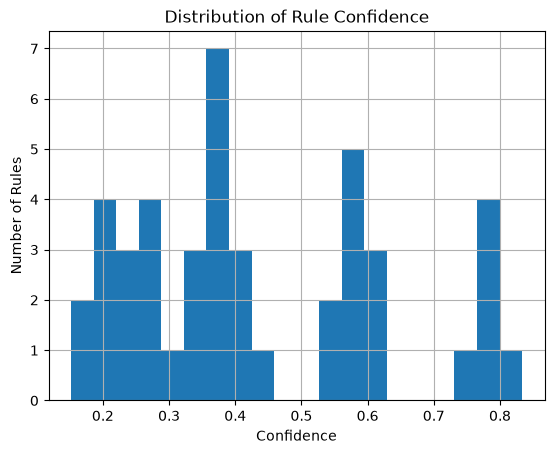

In [ ]:
import matplotlib.pyplot as plt

rules_all["confidence"].hist(bins=20)

plt.title("Distribution of Rule Confidence")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()

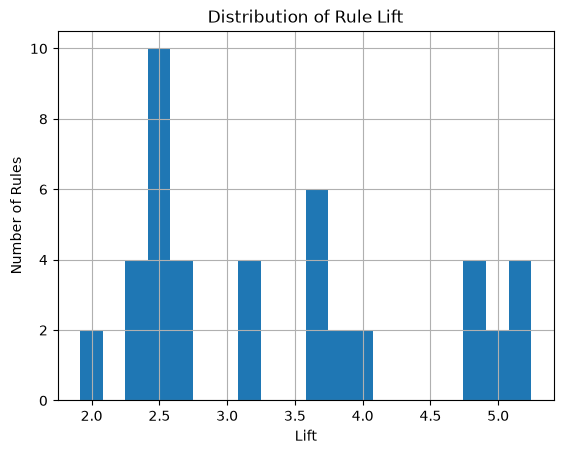

In [ ]:
rules_all["lift"].hist(bins=20)

plt.title("Distribution of Rule Lift")
plt.xlabel("Lift")
plt.ylabel("Number of Rules")
plt.show()

In [ ]:
# Inspect the strongest rules

rules_all[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].sort_values(
    ["confidence", "lift"],
    ascending=False
).head(20)

,antecedents,consequents,support,confidence,lift
27,"frozenset({S03, S02})",frozenset({S01}),0.034286,0.833333,3.696662
40,"frozenset({S15, S11})",frozenset({S12}),0.029143,0.796875,5.242599
26,"frozenset({S03, S01})",frozenset({S02}),0.034286,0.789474,5.145545
32,"frozenset({S06, S08})",frozenset({S07}),0.030286,0.773723,4.996364
34,"frozenset({S08, S07})",frozenset({S06}),0.030286,0.768116,4.843974
38,"frozenset({S12, S15})",frozenset({S11}),0.029143,0.750000,4.772727
1,frozenset({S04}),frozenset({S05}),0.095714,0.614679,3.918718
0,frozenset({S05}),frozenset({S04}),0.095714,0.610200,3.918718
13,frozenset({S13}),frozenset({S01}),0.082571,0.599585,2.659756
4,frozenset({S12}),frozenset({S11}),0.089429,0.588346,3.744019


In [ ]:
# 0.30 sits between the 25th percentile (0.265) and median (0.380)
# It gives a reasonable balance: rules with very low confidence are removed
MIN_CONFIDENCE = 0.30
# minimum lift of 2 because the observed lift values were already high, 
# ranging from approximately 1.92 to 5.24, 
# and a lift of 2 represents a strong positive association.
MIN_LIFT = 2.00

#Apply the selected confidence and lift thresholds to filter the rules
rules_filtered = rules_all[
    (rules_all["confidence"] >= MIN_CONFIDENCE) &
    (rules_all["lift"] >= MIN_LIFT)
].copy().reset_index(drop=True)

print("Rules before threshold filtering:", len(rules_all))
print("Rules after threshold filtering:", len(rules_filtered))
print("Rules removed:", len(rules_all) - len(rules_filtered))



Rules before threshold filtering: 44
Rules after threshold filtering: 29
Rules removed: 15


### Confidence and Lift Threshold Selection

The confidence and lift distributions were examined before selecting the final
thresholds. This ensured that the cutoffs were based on the rules generated from
the dataset rather than being chosen arbitrarily.

A minimum confidence of **0.30** was selected to retain rules where the
consequent occurs reasonably often when the antecedent occurs.

A minimum lift of **2.00** was selected to retain positive associations.
A lift greater than 1 indicates that the antecedent and consequent occur together
more often than would be expected if they were independent.

## Redundancy Removal

In [ ]:
rules_clean = rules_filtered.copy()

print("Rules before redundancy removal:", len(rules_clean))

Rules before redundancy removal: 29


### 1. Remove bidirectional duplicates

In [ ]:
# Remove bidirectional duplicate rules
# A canonical key treats A -> B and B -> A as the same item relationship.

def bidirectional_key(row):
    left = tuple(sorted(row["antecedents"]))
    right = tuple(sorted(row["consequents"]))

    return tuple(sorted([left, right]))

rules_clean["direction_key"] = rules_clean.apply(
    bidirectional_key,
    axis=1
)

# Keep the stronger rule based first on confidence and then lift
rules_clean = (
    rules_clean
    .sort_values(
        ["confidence", "lift"],
        ascending=False
    )
    .drop_duplicates(
        subset="direction_key",
        keep="first"
    )
    .reset_index(drop=True)
)

print("Rules after bidirectional duplicate removal:", len(rules_clean))

Rules after bidirectional duplicate removal: 21


### 2. Remove Subset-redundant rules

In [ ]:
def remove_subset_redundant_rules(rules):
    """
    Remove a rule when a simpler antecedent predicts the same consequent
    with equal or better confidence.
    """

    keep = []

    for i, rule in rules.iterrows():
        redundant = False

        for j, simpler_rule in rules.iterrows():

            if i == j:
                continue

            # Consequents must be the same
            same_consequent = (
                rule["consequents"] == simpler_rule["consequents"]
            )

            # Simpler antecedent must be a proper subset
            simpler_antecedent = (
                simpler_rule["antecedents"] < rule["antecedents"]
            )

            # Simpler rule must perform at least as well
            equally_or_more_confident = (
                simpler_rule["confidence"] >= rule["confidence"]
            )

            if (
                same_consequent
                and simpler_antecedent
                and equally_or_more_confident
            ):
                redundant = True
                break

        keep.append(not redundant)

    return rules.loc[keep].reset_index(drop=True)


before_subset = len(rules_clean)

rules_clean = remove_subset_redundant_rules(rules_clean)

after_subset = len(rules_clean)

print("Rules before subset redundancy removal:", before_subset)
print("Rules after subset redundancy removal:", after_subset)
print("Subset-redundant rules removed:", before_subset - after_subset)

Rules before subset redundancy removal: 21
Rules after subset redundancy removal: 21
Subset-redundant rules removed: 0


In [ ]:
# Remove temporary helper column
rules_clean = rules_clean.drop(
    columns=["direction_key"],
    errors="ignore"
)

# Rank the remaining rules
rules_clean = rules_clean.sort_values(
    ["confidence", "lift"],
    ascending=False
).reset_index(drop=True)

rules_clean[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
0,"frozenset({S03, S02})",frozenset({S01}),0.034286,0.833333,3.696662
1,"frozenset({S15, S11})",frozenset({S12}),0.029143,0.796875,5.242599
2,"frozenset({S03, S01})",frozenset({S02}),0.034286,0.789474,5.145545
3,"frozenset({S06, S08})",frozenset({S07}),0.030286,0.773723,4.996364
4,"frozenset({S08, S07})",frozenset({S06}),0.030286,0.768116,4.843974
5,"frozenset({S12, S15})",frozenset({S11}),0.029143,0.750000,4.772727
6,frozenset({S04}),frozenset({S05}),0.095714,0.614679,3.918718
7,frozenset({S13}),frozenset({S01}),0.082571,0.599585,2.659756
8,frozenset({S12}),frozenset({S11}),0.089429,0.588346,3.744019
9,frozenset({S07}),frozenset({S06}),0.090571,0.584871,3.688375


In [ ]:
print("Initial association rules:", len(rules_all))
print("After confidence/lift thresholds:", len(rules_filtered))
print("After redundancy removal:", len(rules_clean))
print(
    "Total rules removed:",
    len(rules_all) - len(rules_clean)
)

Initial association rules: 44
After confidence/lift thresholds: 29
After redundancy removal: 21
Total rules removed: 23


In [ ]:
rules_clean.to_pickle("../outputs/clean_association_rules.pkl")
rules_clean.to_csv(
    "../outputs/clean_association_rules.csv",
    index=False
)

print("Clean association rules saved successfully.")

Clean association rules saved successfully.


## Role 3 Summary

Association rules were generated from the frequent itemsets produced using the minimum support threshold selected by Member 2. Rather than selecting confidence and lift thresholds arbitrarily, their distributions and
percentiles were first examined.

Based on the observed distributions, a minimum confidence of **[0.30]** and a
minimum lift of **[2.00]** were selected. Confidence measures how reliably the consequent occurs when the antecedent occurs, while lift measures the strength of the relationship compared with what would be expected if the items were independent

The threshold filtering reduced the rules from **[44]** to
**[29]**. Redundancy cleanup was then performed by removing
bidirectional duplicates and subset-redundant rules. For bidirectional pairs,
the stronger rule was retained based on confidence and lift.

After redundancy removal, **[21]** rules remained. The cleaned rules
were then saved for Member 4 to perform show-name translation, interpretation, and temporal validation.